In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import os
import mne

mne.set_log_level('WARNING')

# Traverse the directory 'EEG_Data' to find all files within it
file_names=[]
for dirname, _, filenames in os.walk('EEG_Data'):
    for filename in filenames:
        file_names.append(os.path.join(dirname, filename))

print(file_names)

['EEG_Data/eeg_record34.mat', 'EEG_Data/eeg_record30.mat', 'EEG_Data/eeg_record21.mat', 'EEG_Data/eeg_record31.mat', 'EEG_Data/eeg_record32.mat', 'EEG_Data/eeg_record18.mat', 'EEG_Data/eeg_record28.mat', 'EEG_Data/eeg_record6.mat', 'EEG_Data/eeg_record17.mat', 'EEG_Data/eeg_record16.mat', 'EEG_Data/eeg_record27.mat', 'EEG_Data/eeg_record13.mat', 'EEG_Data/eeg_record29.mat', 'EEG_Data/eeg_record23.mat', 'EEG_Data/eeg_record8.mat', 'EEG_Data/eeg_record11.mat', 'EEG_Data/eeg_record7.mat', 'EEG_Data/eeg_record10.mat', 'EEG_Data/eeg_record24.mat', 'EEG_Data/eeg_record33.mat', 'EEG_Data/eeg_record12.mat', 'EEG_Data/eeg_record5.mat', 'EEG_Data/eeg_record3.mat', 'EEG_Data/eeg_record25.mat', 'EEG_Data/eeg_record26.mat', 'EEG_Data/eeg_record22.mat', 'EEG_Data/eeg_record9.mat', 'EEG_Data/eeg_record1.mat', 'EEG_Data/eeg_record19.mat', 'EEG_Data/eeg_record4.mat', 'EEG_Data/eeg_record15.mat', 'EEG_Data/eeg_record14.mat', 'EEG_Data/eeg_record20.mat', 'EEG_Data/eeg_record2.mat']


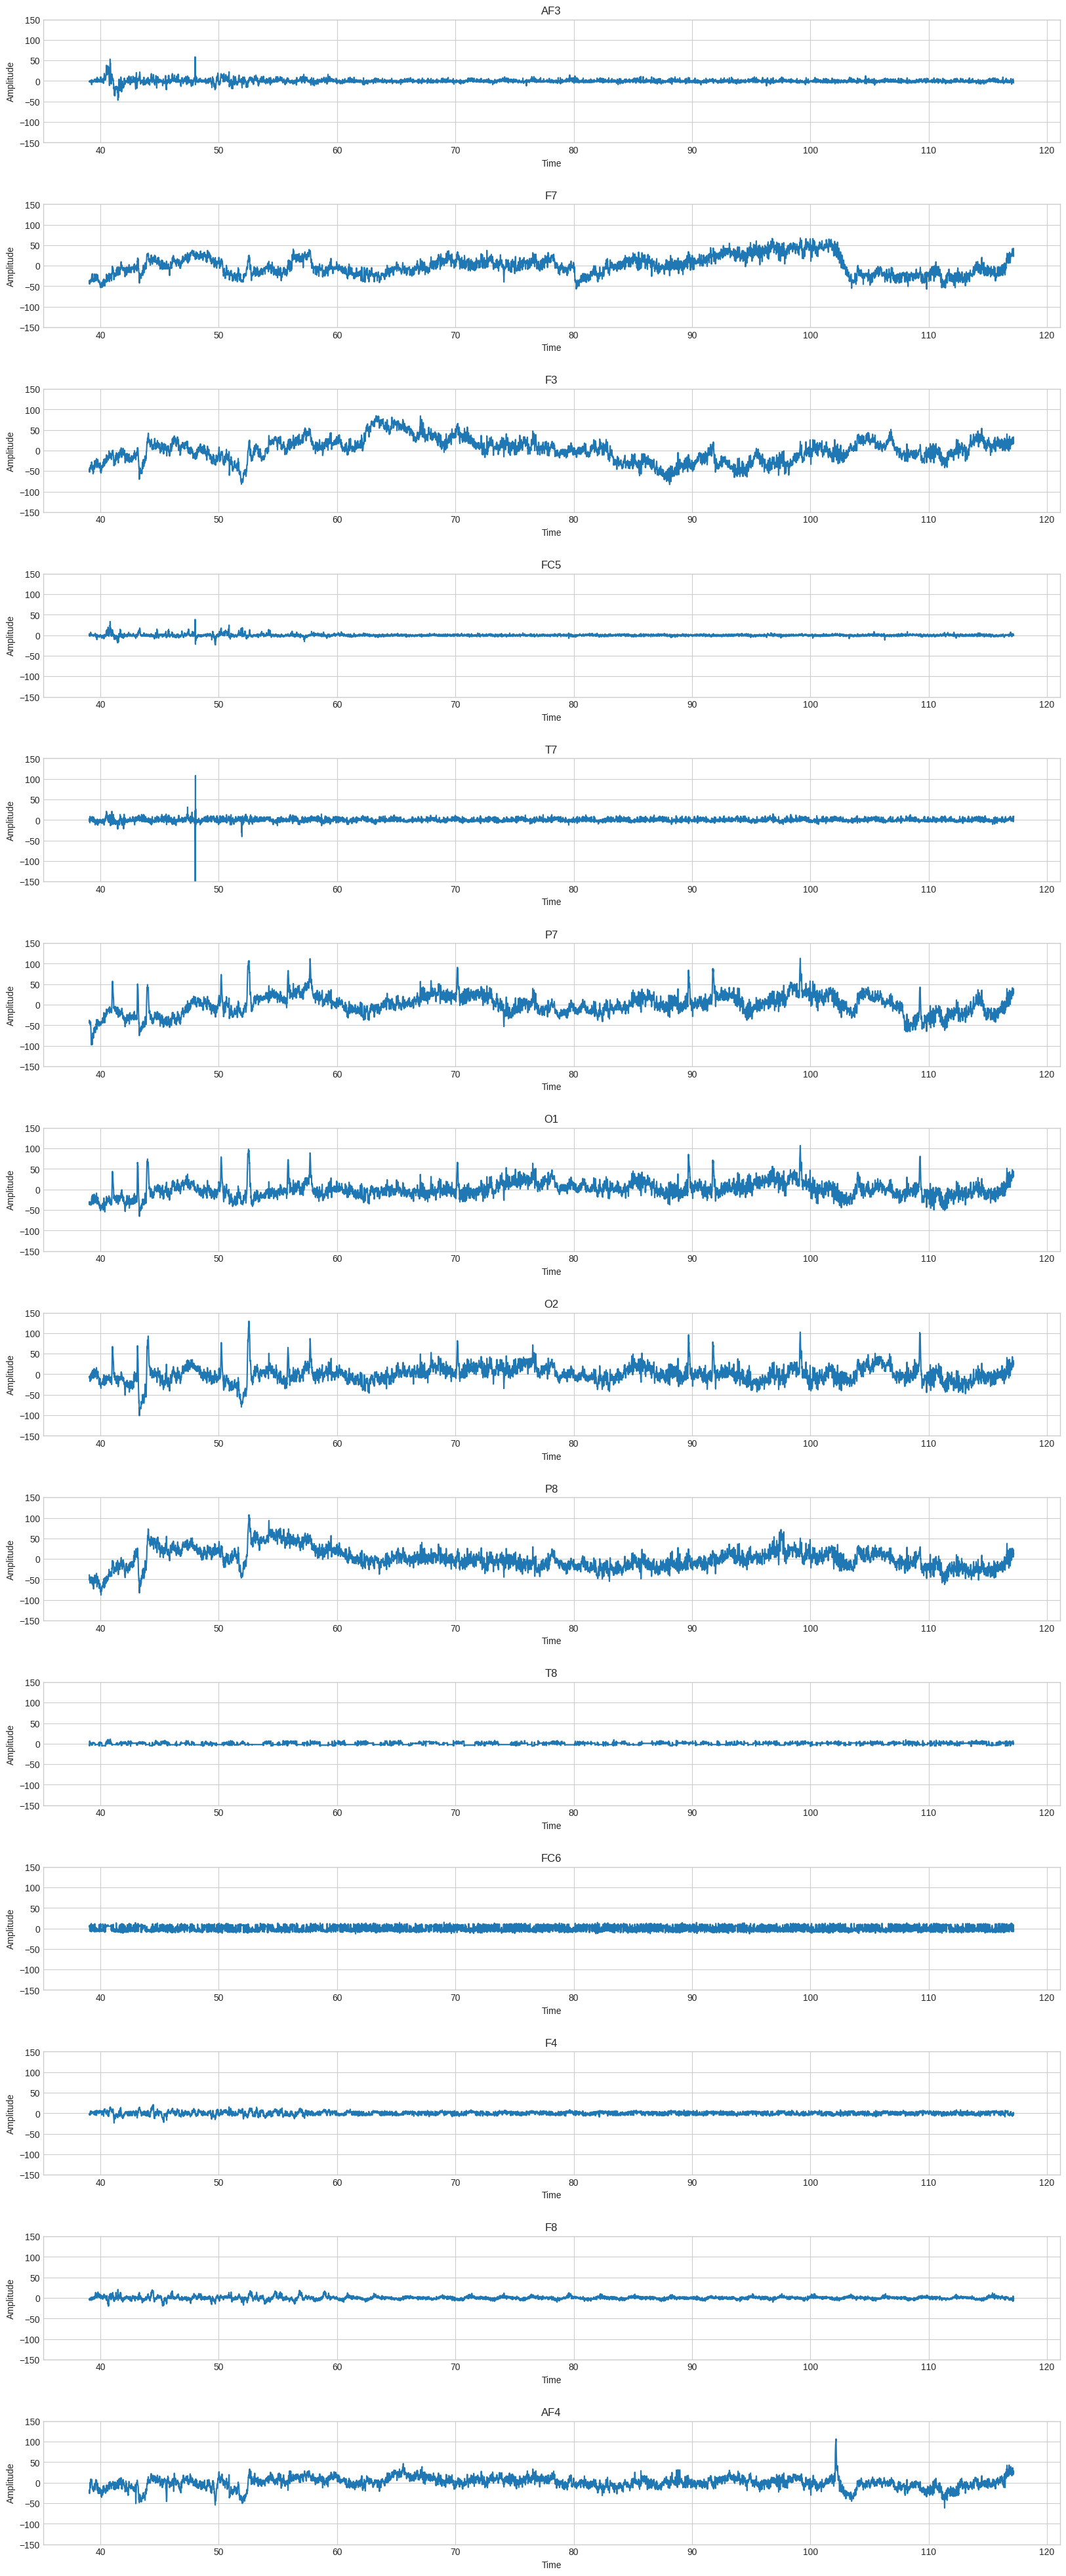

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

# There are 14 channels, the first one is in position 3
fig, ax = plt.subplots(14, 1)
fig.set_figwidth(20)
fig.set_figheight(50)
fig.subplots_adjust(hspace=0.5)

mat = scipy.io.loadmat(file_names[1])
data = mat['o']['data'][0, 0]
FS = mat['o']['sampFreq'][0][0][0][0]
channels = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']

# Create a time vector in seconds for the selected samples
t = np.arange(5000, 15000) / FS

for i in range(14):
    segment = data[5000:15000, i + 3]
    data_ave = segment - np.mean(segment)
    ax[i].plot(t, data_ave)
    ax[i].set_title(channels[i])
    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('Amplitude')
    ax[i].set_ylim(-150, 150)
    ax[i].grid(True)


According to the previous plots, F7, F3, P7, O1, O2, P8, AF4 are useful channels, so those will be the one kept for the implementation.

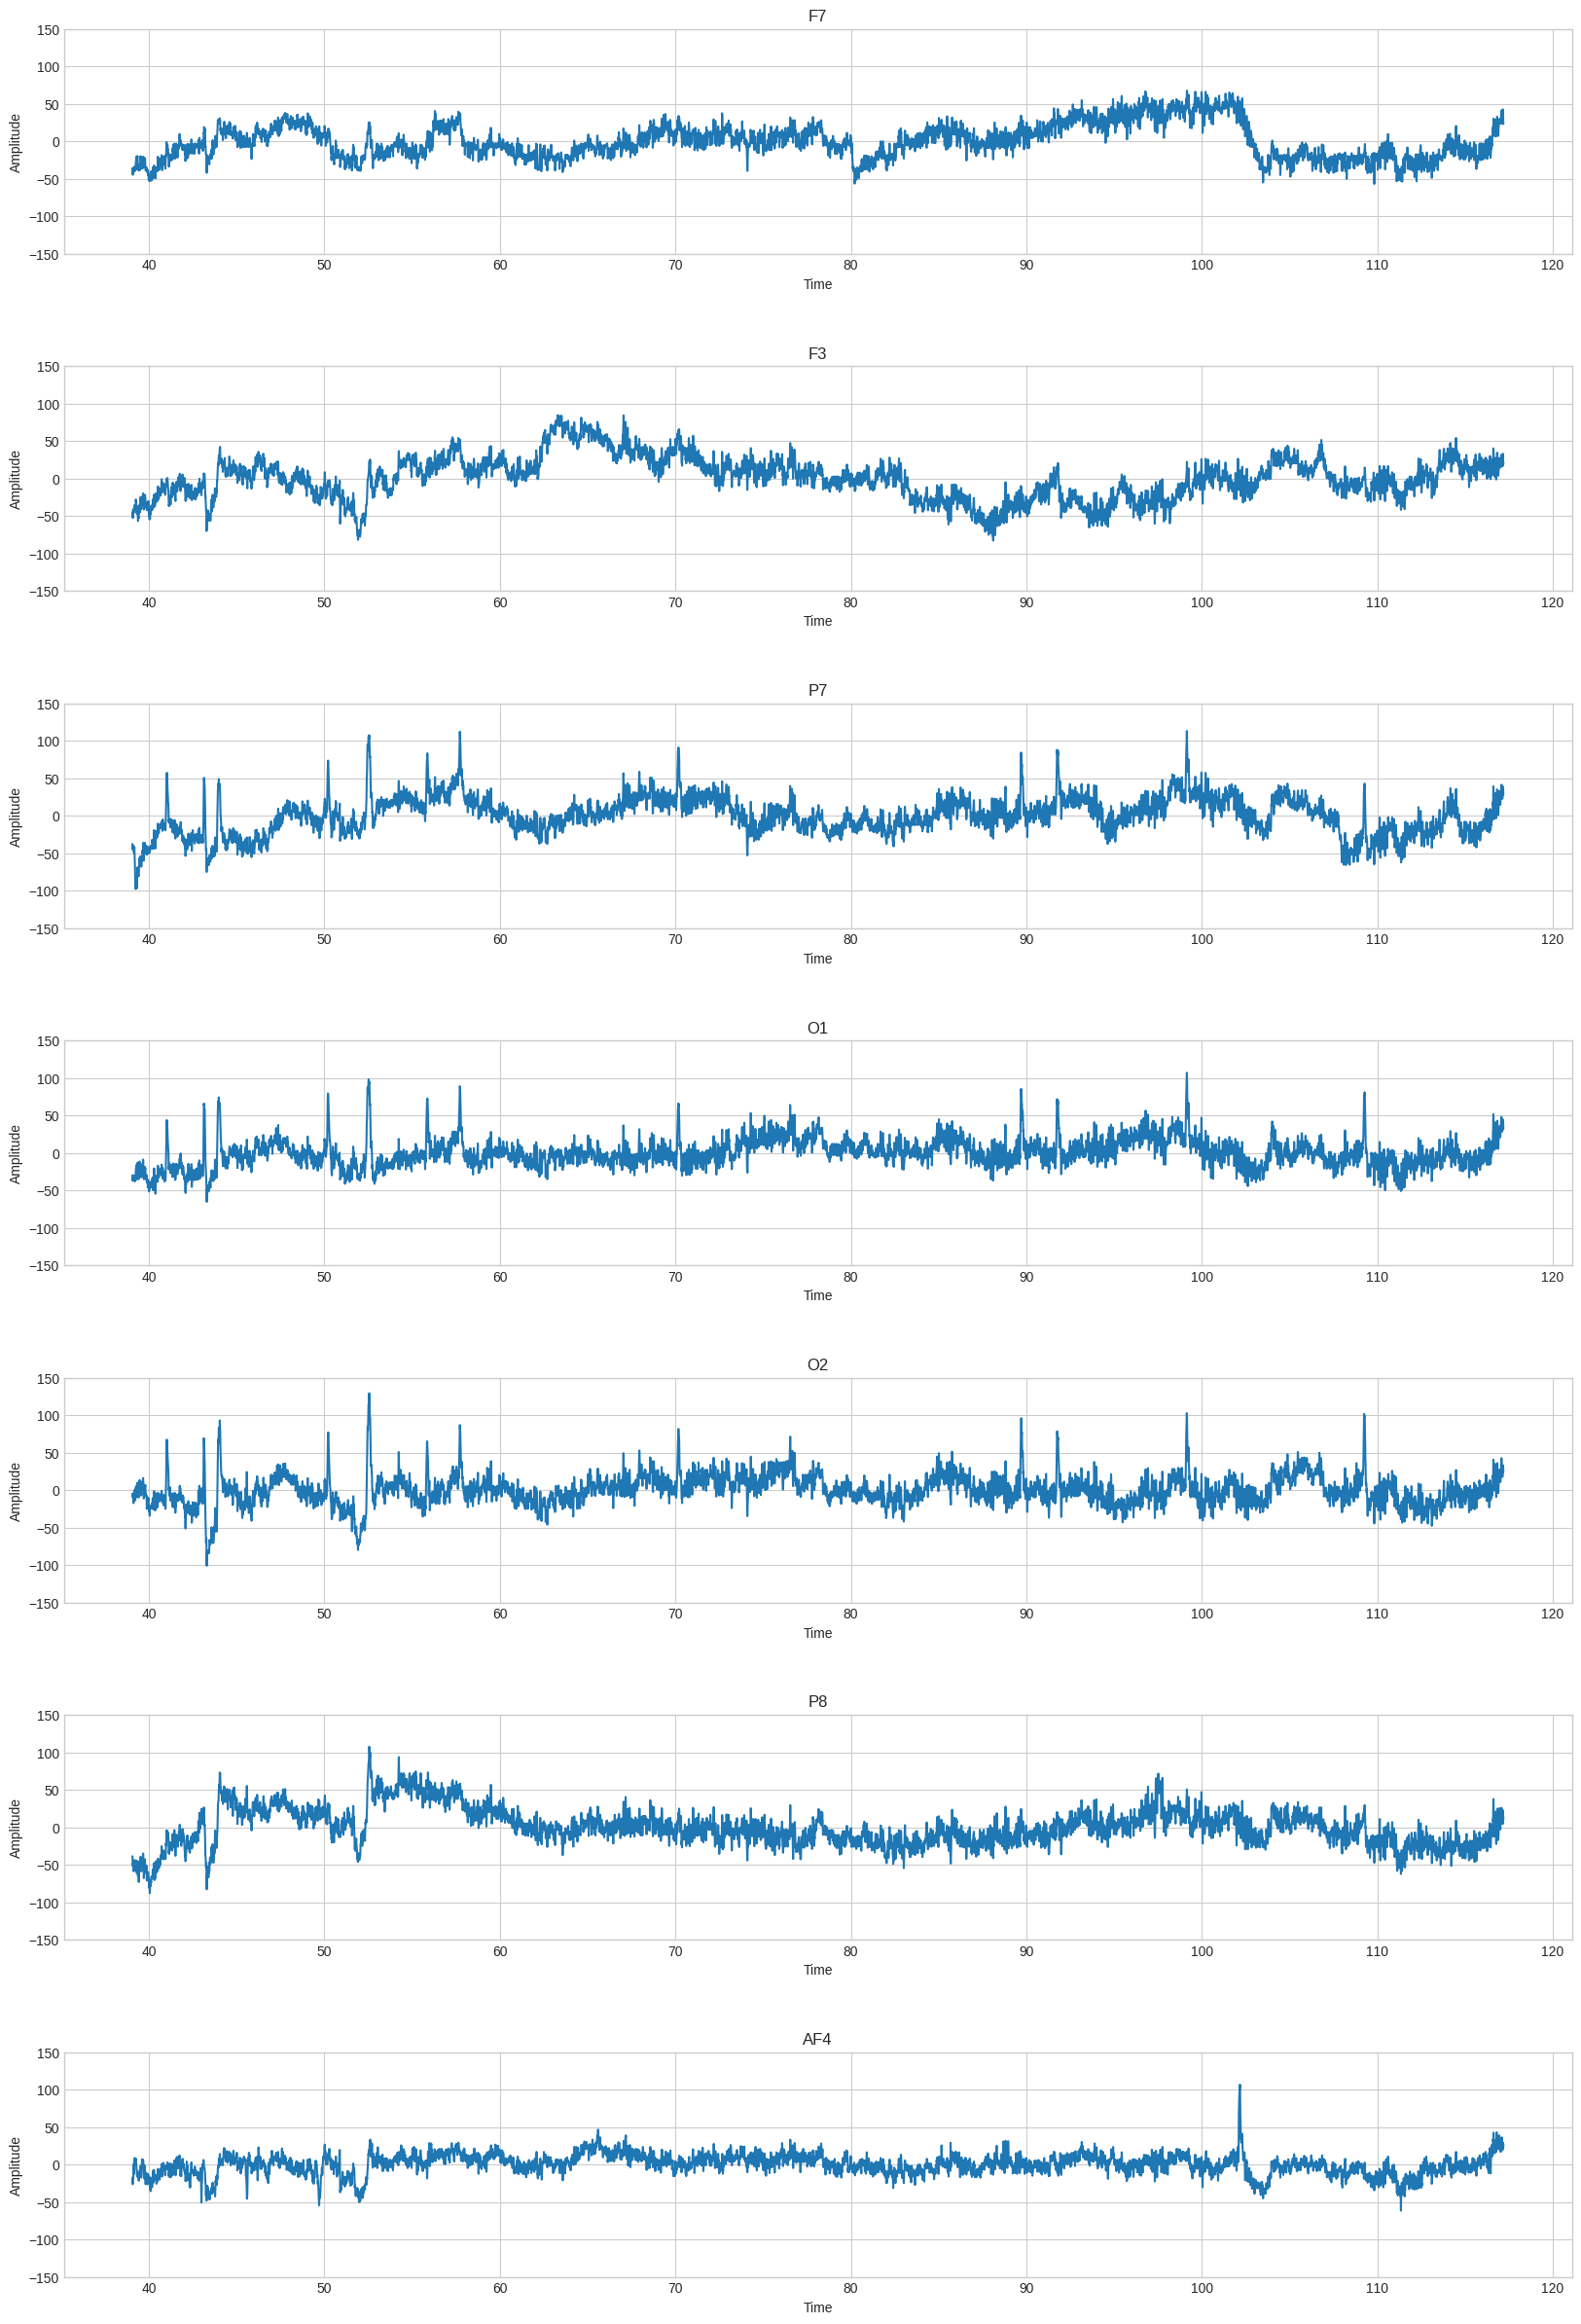

In [4]:
# Define the useful channels (indices in the data) and their corresponding names.
useful_channels = [4, 5, 8, 9, 10, 11, 16]  # F7,F3,P7,O1,O2,P8,AF4

fig, ax = plt.subplots(7, 1, sharex=True)
fig.set_figwidth(20)
fig.set_figheight(30)
fig.subplots_adjust(hspace=0.5)

# Create a time vector in seconds for the selected samples
t = np.arange(5000, 15000) / FS

for j, i in enumerate(useful_channels):
    # For the channel index, adjust the title using channels[i-3].
    segment = data[5000:15000, i]
    data_ave = segment - np.mean(segment)
    ax[j].plot(t, data_ave)
    ax[j].set_title(channels[i - 3])
    ax[j].set_xlabel('Time')
    ax[j].set_ylabel('Amplitude')
    ax[j].set_ylim(-150, 150)
    ax[j].tick_params(axis='x', labelbottom=True)
    ax[j].grid(True)

plt.show()

The states seem to be defined arbitrarily as 10 min adjacent periods.
1st 10 minutes of data(t=0 min to t=10 min) is for "focussed" state
2nd 10 minutes of data(t=10 min to t=20 min) is for "unfocussed" state
Remaining data(t=20 min to onwards) is for "Drowsed" state

In [5]:
# Samples per state = 128 samples/sec x 60 sec/min x 10 min
marker=128*60*10

useful_file_index = [3,4,5,6,7,10,11,12,13,14,17,18,19,20,21,24,25,26,27,31,32,33,34]

# Number of usefull chanels
chan_num=7

trail_names=[]

# The processed data will be stored here
data_focus={}
data_unfocus={}
data_drowsy={}

# These will keep the raw data
focus={}
unfocus={}
drowsy={}

i=1
# Iterates over the list of filenames
for index,filename in enumerate(filenames):
    # Checks if the file index is in the list of useful file indices
    if int(filename.split('d')[1].split('.')[0]) in useful_file_index:
        # Loads the MATLAB file and extracts the trial name
        mat = scipy.io.loadmat(file_names[index])
        trail_names.append(filename.split('.')[0])

        # Extracts and stores data segments for focused, unfocused, and drowsy states from the useful channels
        data_focus[trail_names[-1]]=mat['o']['data'][0,0][0:marker,useful_channels].copy()
        data_unfocus[trail_names[-1]]=mat['o']['data'][0,0][marker:2*marker,useful_channels].copy()
        data_drowsy[trail_names[-1]]=mat['o']['data'][0,0][2*marker:3*marker,useful_channels].copy()
        
        focus[trail_names[-1]]=mat['o']['data'][0,0][0:marker,useful_channels].copy()
        unfocus[trail_names[-1]]=mat['o']['data'][0,0][marker:2*marker,useful_channels].copy()
        drowsy[trail_names[-1]]=mat['o']['data'][0,0][2*marker:3*marker,useful_channels].copy()

print(data_focus['eeg_record3'].shape)

(76800, 7)


In [ ]:
from tensorflow.keras.utils import to_categorical

# Original list of 14 channel names (corresponds to columns 3–16 of the MAT file)
channels = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
# Absolute indices in the MAT file of the 7 useful channels
useful_channels = [4,5,8,9,10,11,16]
# Adjust to 0-based indices within `channels` by subtracting 3
channels_useful = [channels[i-3] for i in useful_channels]


# Parameters
sfreq = 128            # Hz, as used in marker = 128*60*10
epoch_len = 0.5        # seconds per window
label_map = {'focus':0, 'unfocus':1, 'drowsy':2}

X_list, y_list = [], []

for name in trail_names:
    for state, data_dict in zip(['focus','unfocus','drowsy'],
                                [data_focus, data_unfocus, data_drowsy]):
        # data_dict[name]: array (n_samples, n_channels)
        raw_data = data_dict[name].T  # (n_channels, n_samples)
        raw_data = (raw_data - raw_data.mean(axis=1, keepdims=True)) \
           / (raw_data.std(axis=1, keepdims=True) + 1e-6)
        info = mne.create_info(ch_names=channels_useful, sfreq=sfreq, ch_types=['eeg']*len(channels_useful))
        raw = mne.io.RawArray(raw_data, info)
        raw.filter(1., 40., fir_design='firwin')  # 1–40 Hz band

        # 1 s epochs with no overlap (0.25 s overlap set by overlap parameter)
        epochs = mne.make_fixed_length_epochs(raw,
                                              duration=epoch_len,
                                              overlap=0.25,
                                              preload=True)
        X_epoch = epochs.get_data()      # (n_epochs, n_channels, n_times)
        n_epochs = X_epoch.shape[0]

        X_list.append(X_epoch)
        y_list.append(np.full(n_epochs, label_map[state]))

# stack everything
X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
y_cat = to_categorical(y)
print(f"Shape X: {X.shape}, shape y: {y.shape}")


2025-06-01 19:43:18.327675: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Shape X: (165531, 7, 64), shape y: (165531,)


In [7]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, DepthwiseConv2D, SeparableConv2D
from tensorflow.keras.layers import BatchNormalization, Activation, AveragePooling2D
from tensorflow.keras.layers import Dropout, Flatten, Dense
from tensorflow.keras.models import Model

def EEGNet(nb_classes, Chans, Samples,
           dropoutRate=0.05, kernLength=128, F1=128, D=2, F2=256, norm_rate=0.5):
    input1 = Input(shape=(Chans, Samples, 1))
    # Block 1
    x = Conv2D(F1, (1, kernLength), padding='same', use_bias=False)(input1)
    x = BatchNormalization()(x)
    x = DepthwiseConv2D((Chans, 1), use_bias=False, depth_multiplier=D,
                        depthwise_constraint=tf.keras.constraints.max_norm(1.))(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 4))(x)
    x = Dropout(dropoutRate)(x)
    
    # Block 2
    x = SeparableConv2D(F2, (1, 16), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 8))(x)
    x = Dropout(dropoutRate)(x)
    flatten = Flatten(name='flatten')(x)
    
    # Classifier
    dense    = Dense(nb_classes, kernel_constraint=tf.keras.constraints.max_norm(norm_rate))(flatten)
    softmax  = Activation('softmax', name='softmax')(dense)
    return Model(inputs=input1, outputs=softmax)


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LambdaCallback

n_channels, n_times = X.shape[1], X.shape[2]
n_classes = y_cat.shape[1]

model = EEGNet(nb_classes=n_classes, Chans=n_channels, Samples=n_times)
model.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
y_train_cat = to_categorical(y_train)
y_test_cat  = to_categorical(y_test)

# --- reshape 4D to Conv2D ---
X_train = X_train.reshape(-1, n_channels, n_times, 1)
X_test  = X_test.reshape(-1, n_channels, n_times, 1)

# --- callbacks ---
es = EarlyStopping(
    monitor='val_loss',
    patience=15,             
    restore_best_weights=True
)
ckpt = ModelCheckpoint(
    'best_eegnet_weights.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)
rlp = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,    
    patience=5,    
    min_lr=1e-5,
    verbose=1
)
lr_printer = LambdaCallback(
    on_epoch_end=lambda epoch, logs: 
        print(f" → lr: {K.get_value(model.optimizer.lr):.6f}")
)

callbacks = [es, ckpt, rlp]

# --- training ---
history = model.fit(
    X_train, y_train_cat,
    batch_size=64,
    epochs=500,
    validation_split=0.2,    
    callbacks=[es, ckpt],
    verbose=2
)
model.save('eegnet_model.h5') 
model.save_weights('eegnet_weights.h5')


2025-06-01 19:43:29.375286: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/500
828/828 - 75s - loss: 0.8637 - accuracy: 0.5857 - val_loss: 0.7945 - val_accuracy: 0.6271 - 75s/epoch - 90ms/step
Epoch 2/500
828/828 - 73s - loss: 0.7536 - accuracy: 0.6502 - val_loss: 0.7787 - val_accuracy: 0.6449 - 73s/epoch - 88ms/step
Epoch 3/500
828/828 - 73s - loss: 0.6869 - accuracy: 0.6887 - val_loss: 0.6711 - val_accuracy: 0.6985 - 73s/epoch - 88ms/step
Epoch 4/500
828/828 - 73s - loss: 0.6317 - accuracy: 0.7208 - val_loss: 0.6086 - val_accuracy: 0.7308 - 73s/epoch - 88ms/step
Epoch 5/500
828/828 - 73s - loss: 0.5811 - accuracy: 0.7500 - val_loss: 0.5737 - val_accuracy: 0.7597 - 73s/epoch - 88ms/step
Epoch 6/500
828/828 - 73s - loss: 0.5401 - accuracy: 0.7728 - val_loss: 0.5217 - val_accuracy: 0.7820 - 73s/epoch - 88ms/step
Epoch 7/500
828/828 - 73s - loss: 0.5048 - accuracy: 0.7910 - val_loss: 0.5084 - val_accuracy: 0.7994 - 73s/epoch - 88ms/step
Epoch 8/500
828/828 - 73s - loss: 0.4776 - accuracy: 0.8057 - val_loss: 0.4875 - val_accuracy: 0.8002 - 73s/epoch - 88

In [ ]:
loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"EEGNet accuracy: {acc*100:.2f}%")

EEGNet accuracy: 95.64%
